In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
from tqdm import tqdm

In [4]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml(name="mnist_784")
print(mnist.keys())

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])


In [5]:
data = mnist.data
labels= mnist.target

print(labels)

0        5
1        0
2        4
3        1
4        9
        ..
69995    2
69996    3
69997    4
69998    5
69999    6
Name: class, Length: 70000, dtype: category
Categories (10, object): ['0', '1', '2', '3', ..., '6', '7', '8', '9']


In [6]:
n = np.random.choice(np.arange(data.shape[0]+1))
print (n)

7629


In [7]:
test_img=data.iloc[n].values
test_label= mnist.target.iloc[n]
print(test_img.shape)

(784,)


Image label: 0


C:\Users\singh\AppData\Local\Temp\ipykernel_19584\440887942.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  side_length = int(np.sqrt(test_img.shape))


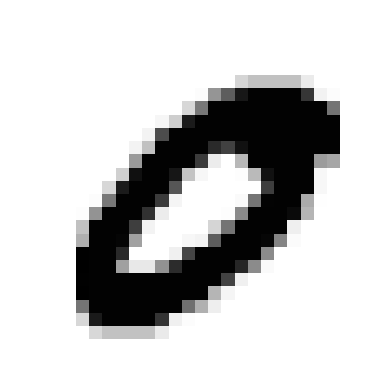

In [8]:
side_length = int(np.sqrt(test_img.shape))
reshaped_test_img = test_img.reshape(side_length, side_length)

print("Image label: " + str(test_label))


plt.imshow(reshaped_test_img, cmap="Greys")
plt.axis('off')
plt.show()

In [9]:
w1 = np.ones((784, 4)) * 0.01
z1 = np.dot(data, w1)
print(z1.shape)

w2 = np.ones((4, 10))
z2 = np.dot(z1, w2)
print(z2.shape)

(70000, 4)
(70000, 10)


In [10]:
def sigmoid(z: np.ndarray) -> np.ndarray:
    return 1.0 / (1.0 + np.exp(-z))
def relu(z: np.ndarray) -> np.ndarray:
    return np.maximum(0, z)
def tanh(z: np.ndarray) -> np.ndarray:
    return np.tanh(z)
def leaky_relu(z: np.ndarray) -> np.ndarray:
    return np.where(z > 0, z, z * 0.01)

In [11]:
def softmax(z: np.ndarray) -> np.ndarray:
    e = np.exp(z - np.max(z))
    return e / np.sum(e, axis=0)

In [12]:
def normalize(x: np.ndarray) -> np.ndarray:
    return (x - np.min(x)) / (np.max(x) - np.min(x))

In [13]:
def one_hot_encode(x: np.ndarray, num_labels: int) -> np.ndarray:
    return np.eye(num_labels)[x]

In [14]:
def derivative(function_name: str, z: np.ndarray) -> np.ndarray:
    if function_name == "sigmoid":
        return sigmoid(z) * (1 - sigmoid(z))
    if function_name == "tanh":
        return 1 - np.square(tanh(z))
    if function_name == "relu":
        y = (z > 0) * 1
        return y
    if function_name == "leaky_relu":
        return  np.where(z > 0, 1, 0.01)
    return "No such activation"

In [15]:
class NN(object):
    def __init__(self, X: np.ndarray, y: np.ndarray, X_test: np.ndarray, y_test: np.ndarray, activation: str, num_labels: int, architecture: list[int]):
        self.X = normalize(X) # normalize training data in range 0,1
        assert np.all((self.X >= 0) | (self.X <= 1)) # test that normalize succeded
        self.X, self.X_test = X.copy(), X_test.copy()
        self.y, self.y_test = y.copy(), y_test.copy()
        self.layers = {} # define dict to store results of activation
        self.architecture = architecture # size of hidden layers as array  
        self.activation = activation # activation function
        assert self.activation in ["relu", "tanh", "sigmoid", "leaky_relu"]
        self.parameters = {}
        self.num_labels = num_labels
        self.m = X.shape[1]
        self.architecture.append(self.num_labels)
        self.num_input_features = X.shape[0]
        self.architecture.insert(0, self.num_input_features)
        self.L = len(architecture) 
        assert self.X.shape == (self.num_input_features, self.m)
        assert self.y.shape == (self.num_labels, self.m)
        
    def initialize_parameters(self):
        for i in range(1, self.L):
            print(f"Initializing parameters for layer: {i}.")
            self.parameters["w"+str(i)] = np.random.randn(self.architecture[i], self.architecture[i-1]) * 0.01
            self.parameters["b"+str(i)] = np.zeros((self.architecture[i], 1))
    
    
    def forward(self):
        params=self.parameters
        self.layers["a0"] = self.X
        for l in range(1, self.L-1):
            self.layers["z" + str(l)] = np.dot(params["w" + str(l)], 
                                               self.layers["a"+str(l-1)]) + params["b"+str(l)]
            self.layers["a" + str(l)] = eval(self.activation)(self.layers["z"+str(l)])
            assert self.layers["a"+str(l)].shape == (self.architecture[l], self.m)
        self.layers["z" + str(self.L-1)] = np.dot(params["w" + str(self.L-1)],
                                                  self.layers["a"+str(self.L-2)]) + params["b"+str(self.L-1)]
        self.layers["a"+str(self.L-1)] = softmax(self.layers["z"+str(self.L-1)])
        self.output = self.layers["a"+str(self.L-1)]
        assert self.output.shape == (self.num_labels, self.m)
        assert all([s for s in np.sum(self.output, axis=1)])        
        
        cost = - np.sum(self.y * np.log(self.output + 0.000000001))

        return cost, self.layers


    def backpropagate(self):
        derivatives = {}
        dZ = self.output - self.y
        assert dZ.shape == (self.num_labels, self.m)
        dW = np.dot(dZ, self.layers["a" + str(self.L-2)].T) / self.m
        db = np.sum(dZ, axis=1, keepdims=True) / self.m
        dAPrev = np.dot(self.parameters["w" + str(self.L-1)].T, dZ)
        derivatives["dW" + str(self.L-1)] = dW
        derivatives["db" + str(self.L-1)] = db
        
        for l in range(self.L-2, 0, -1):
            
            dZ = dAPrev * derivative(self.activation, self.layers["z" + str(l)])  
            dW = 1. / self.m * np.dot(dZ, self.layers["a" + str(l-1)].T)
            db = 1. / self.m * np.sum(dZ, axis=1, keepdims=True)
            if l > 1:
                dAPrev = np.dot(self.parameters["w" + str(l)].T, (dZ))
            derivatives["dW" + str(l)] = dW
            derivatives["db" + str(l)] = db
        self.derivatives = derivatives
        
        return self.derivatives

    
    def fit(self, lr=0.01, epochs=1000):
        self.costs = [] 
        self.initialize_parameters()
        self.accuracies = {"train": [], "test": []}
        for epoch in tqdm(range(epochs), colour="BLUE"):
            cost, cache = self.forward()
            self.costs.append(cost)
            derivatives = self.backpropagate()            
            for layer in range(1, self.L):
                self.parameters["w"+str(layer)] = self.parameters["w"+str(layer)] - lr * derivatives["dW" + str(layer)]
                self.parameters["b"+str(layer)] = self.parameters["b"+str(layer)] - lr * derivatives["db" + str(layer)]            
            train_accuracy = self.accuracy(self.X, self.y)
            test_accuracy = self.accuracy(self.X_test, self.y_test)
            if epoch % 10 == 0:
                print(f"Epoch: {epoch:3d} | Cost: {cost:.3f} | Accuracy: {train_accuracy:.3f}")
            self.accuracies["train"].append(train_accuracy)
            self.accuracies["test"].append(test_accuracy)
        print("Training terminated")


    def predict(self, x):
        params = self.parameters
        n_layers = self.L - 1
        values = [x]
        for l in range(1, n_layers):
            z = np.dot(params["w" + str(l)], values[l-1]) + params["b" + str(l)]
            a = eval(self.activation)(z)
            values.append(a)
        z = np.dot(params["w"+str(n_layers)], values[n_layers-1]) + params["b"+str(n_layers)]
        a = softmax(z)
        if x.shape[1]>1:
            ans = np.argmax(a, axis=0)
        else:
            ans = np.argmax(a)
        return ans
    
    
    def accuracy(self, X, y):
        P = self.predict(X)
        return sum(np.equal(P, np.argmax(y, axis=0))) / y.shape[1]*100
    
    
    def pickle_model(self, name: str):
        with open("fitted_model_"+ name + ".pickle", "wb") as modelFile:
            pickle.dump(self, modelFile)
    
    
    def plot_counts(self):
        counts = np.unique(np.argmax(self.output, axis=0), return_counts=True)
        plt.bar(counts[0], counts[1], color="navy")
        plt.ylabel("Counts")
        plt.xlabel("y_hat")
        plt.title("Distribution of predictions")
        plt.show()
    
    
    def plot_cost(self, lr):
        plt.figure(figsize=(8, 4))
        plt.plot(np.arange(0, len(self.costs)), self.costs, lw=1, color="orange")
        plt.title(f"Learning rate: {lr}\nFinal Cost: {self.costs[-1]:.5f}", fontdict={
        "family":"sans-serif", 
        "size": "12"})
        plt.xlabel("Epoch")
        plt.ylabel("Cost")
        plt.show()
    
    
    def plot_accuracies(self, lr):
        acc = self.accuracies
        fig = plt.figure(figsize=(6,4))
        ax = fig.add_subplot(111)
        ax.plot(acc["train"], label="train")
        ax.plot(acc["test"], label="test")
        plt.legend(loc="lower right")
        ax.set_title("Accuracy")
        ax.annotate(f"Train: {acc['train'][-1]:.2f}", (len(acc["train"])+4, acc["train"][-1]+2), color="blue")
        ax.annotate(f"Test: {acc['test'][-1]:.2f}", (len(acc["test"])+4, acc["test"][-1]-2), color="orange")
        ax.spines["right"].set_visible(False)
        ax.spines["top"].set_visible(False)
        plt.show()
    
    def __str__(self):                
        return str(self.architecture)

In [16]:
train_test_split_no = 60000
X_train = data.values[:train_test_split_no].T
y_train = labels[:train_test_split_no].values.astype(int)
y_train = one_hot_encode(y_train, 10).T
X_test = data.values[train_test_split_no:].T
y_test = labels[train_test_split_no:].values.astype(int)
y_test = one_hot_encode(y_test, 10).T
X_train.shape, X_test.shape

((784, 60000), (784, 10000))

Initializing parameters for layer: 1.
Initializing parameters for layer: 2.
Initializing parameters for layer: 3.


  2%|█▋                                                                                 | 1/50 [00:08<06:40,  8.18s/it]

Epoch:   0 | Cost: 141432.695 | Accuracy: 23.305


 22%|██████████████████                                                                | 11/50 [01:16<04:30,  6.94s/it]

Epoch:  10 | Cost: 74890.842 | Accuracy: 76.588


...

Epoch:  30 | Cost: 35649.284 | Accuracy: 85.617


 82%|███████████████████████████████████████████████████████████████████▏              | 41/50 [04:38<00:59,  6.64s/it]

Epoch:  40 | Cost: 30663.623 | Accuracy: 86.315


100%|██████████████████████████████████████████████████████████████████████████████████| 50/50 [05:38<00:00,  6.77s/it]


Training terminated


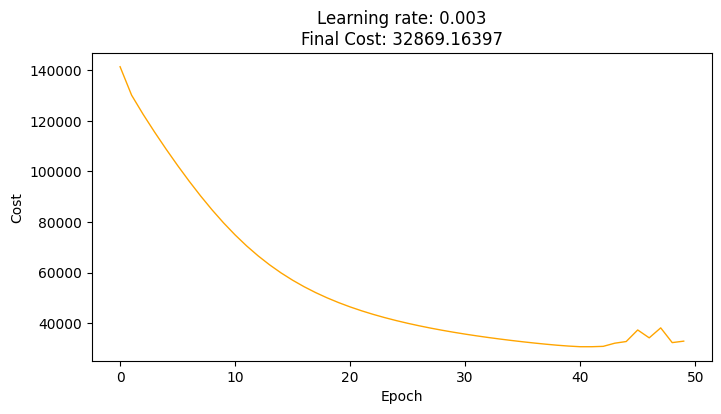

In [17]:
PARAMS = [X_train, y_train, X_test, y_test, "relu", 10, [512, 300]]
nn_relu = NN(*PARAMS)
epochs_relu = 50
lr_relu = 0.003
nn_relu.fit(lr=lr_relu, epochs=epochs_relu)
nn_relu.plot_cost(lr_relu)

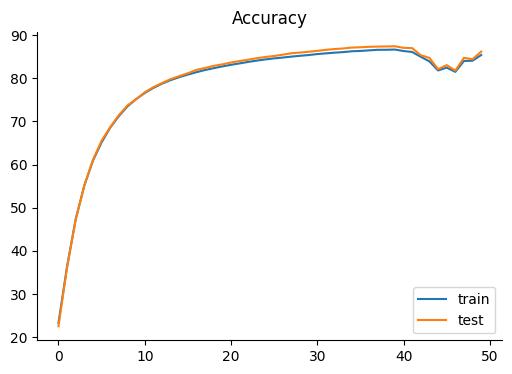

In [18]:
nn_relu.plot_accuracies(lr_relu)

In [21]:
def plot_predictions(model, X_test, labels, rows, cols):
    indexes = np.random.choice(range(X_test.shape[1]), rows * cols)
    fig, ax = plt.subplots(rows, cols, figsize=(5, 4))
    n = 0
    for i in range(rows):
        for j in range(cols):
            ix = indexes[n]
            example = X_test[:, ix].reshape(28,28)
            prediction = model.predict(X_test[:, ix].reshape((X_test[:, ix].shape[0], 1)))        
            subplot = ax[i, j]
            subplot.set_title(f"Prediction: {prediction}\nLabel: {np.argmax(labels[:, ix])}")
            subplot.imshow(example, cmap="Greys")
            subplot.axis('off')
            n += 1
    plt.tight_layout()
    plt.show()

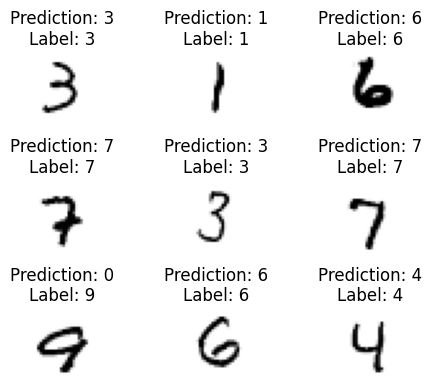

In [22]:
plot_predictions(nn_relu, X_test, y_test, 3, 3)

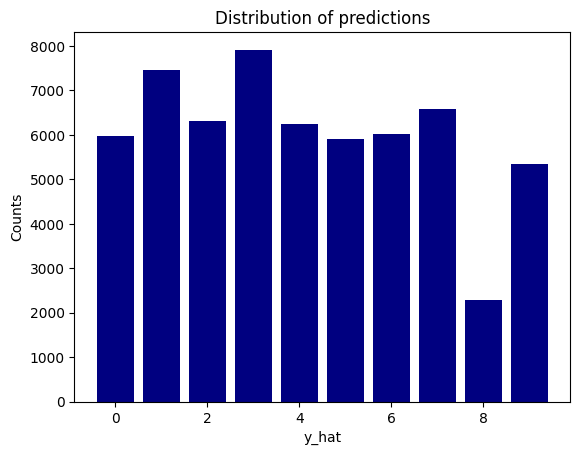

In [23]:
nn_relu.plot_counts()